In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from pathlib import Path
from matplotlib.ticker import FuncFormatter
from matplotlib.dates import YearLocator, DateFormatter

results_output_path = Path('../results/international_incoming_vs_outgoing/')
results_output_path.joinpath('figures').mkdir(parents=True, exist_ok=True)

In [2]:
data_file = Path('../data/T100_domestic/processed/final_enriched_t100_data.parquet')
df = pd.read_parquet(data_file)

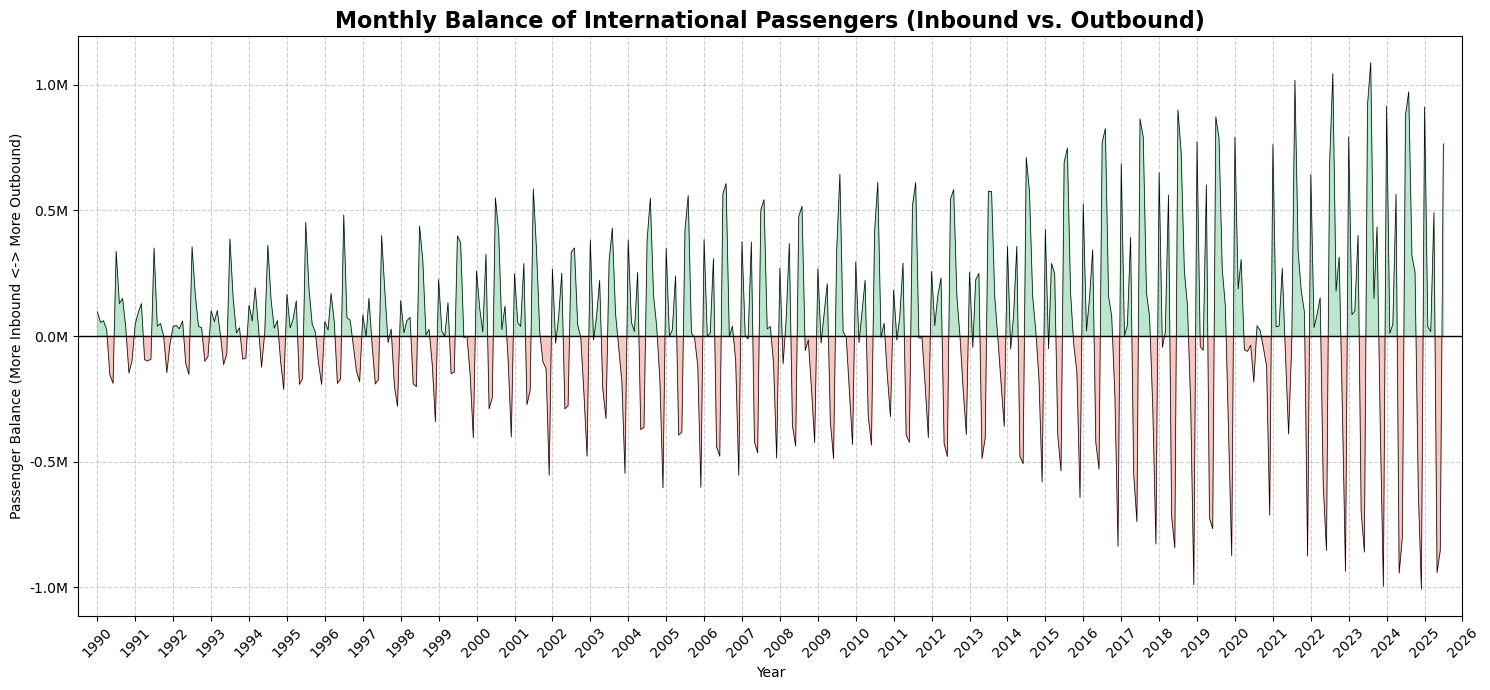

In [3]:
plot_df = df.groupby(['date', 'Travel_type'], as_index=False)['PASSENGERS'].sum()
data = plot_df.loc[plot_df.Travel_type.isin(['Inbound International', 'Outbound International'])]

balance_df = data.pivot(index='date', columns='Travel_type', values='PASSENGERS').fillna(0)
balance_df['balance'] = balance_df['Inbound International'] - balance_df['Outbound International']
balance_df.reset_index(inplace=True)

plt.figure(figsize=(15, 7))
ax = plt.gca() # Get the current axis

sns.lineplot(
    data=balance_df,
    x='date',
    y='balance',
    color='black',
    linewidth=0.5,
    ax=ax
)

# --- Fill the area above/below zero ---
# Fill green for positive (More Inbound)
ax.fill_between(
    balance_df['date'], 0, balance_df['balance'],
    where=(balance_df['balance'] > 0), 
    color='#27AE60', alpha=0.3, interpolate=True
)
# Fill red for negative (More Outbound)
ax.fill_between(
    balance_df['date'], 0, balance_df['balance'],
    where=(balance_df['balance'] <= 0), 
    color='#E74C3C', alpha=0.3, interpolate=True
)

ax.axhline(0, color='black', linewidth=1)
formatter = FuncFormatter(lambda y, pos: f'{y / 1_000_000:.1f}M')
ax.yaxis.set_major_formatter(formatter)
min_date = balance_df['date'].min() - pd.DateOffset(months=6)
max_date = balance_df['date'].max() + pd.DateOffset(months=6)
ax.set_xlim(min_date, max_date)
ax.xaxis.set_major_locator(YearLocator(1))
ax.xaxis.set_major_formatter(DateFormatter('%Y'))

ax.set_title('Monthly Balance of International Passengers (Inbound vs. Outbound)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Passenger Balance (More Inbound <-> More Outbound)')
plt.xticks(rotation=45, ha='center')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
fig = ax.get_figure()
fig.savefig(results_output_path / "figures" / "monthly_balance_international_passengers.png", dpi=300)

## Figure Conclusion

- Hard to interpret
- Clear seasonality
- Balance becomes larger over time
- Brief disruption in 2020, but quick return to normal in 2021
    - This is interesting since overall numbers of passengers was still low at this time 

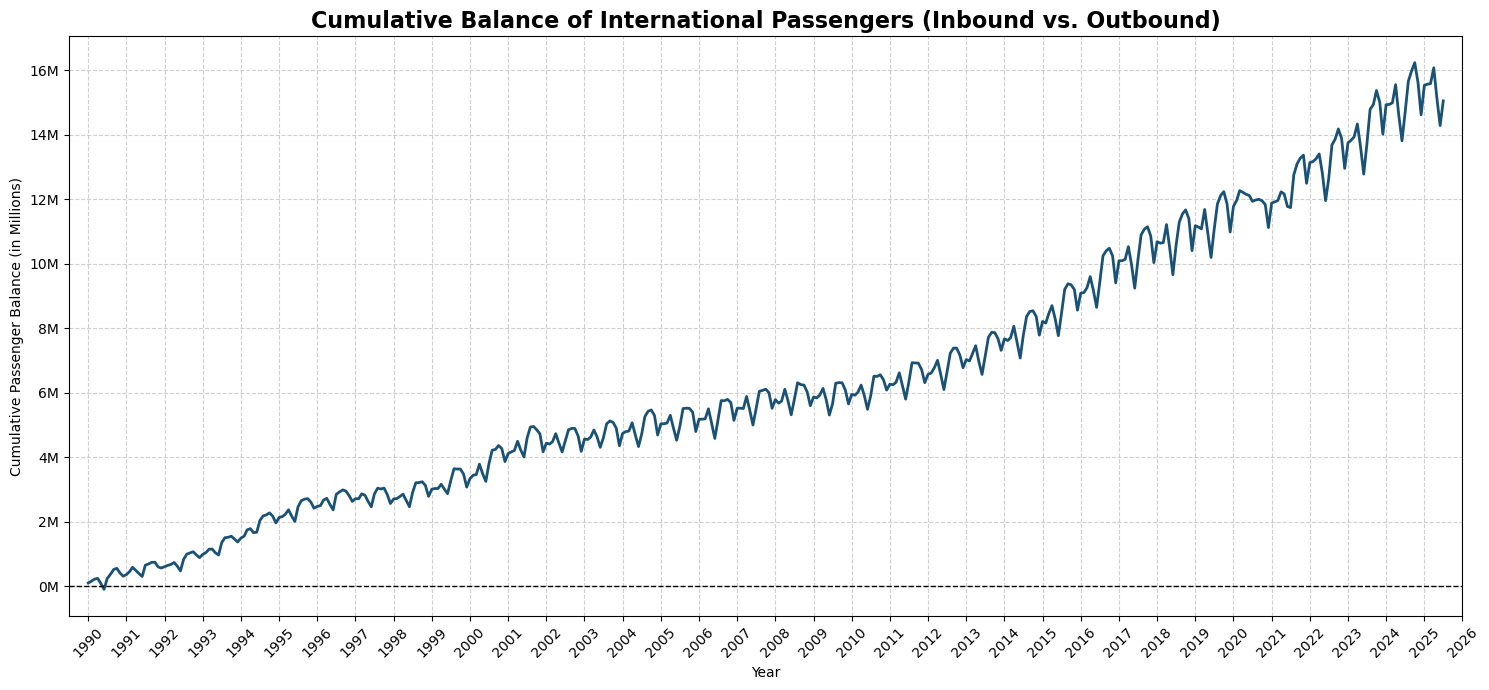

In [4]:
balance_df['cumulative_balance'] = balance_df['balance'].cumsum()

plt.figure(figsize=(15, 7))
ax = sns.lineplot(
    data=balance_df,
    x='date',
    y='cumulative_balance',
    color='#1A5276', # Using the same navy-like color
    linewidth=2
)

ax.axhline(0, color='black', linewidth=1, linestyle='--')
formatter = FuncFormatter(lambda y, pos: f'{y / 1_000_000:.0f}M')
ax.yaxis.set_major_formatter(formatter)
min_date = balance_df['date'].min() - pd.DateOffset(months=6)
max_date = balance_df['date'].max() + pd.DateOffset(months=6)
ax.set_xlim(min_date, max_date)
ax.xaxis.set_major_locator(YearLocator(1))
ax.xaxis.set_major_formatter(DateFormatter('%Y'))

ax.set_title('Cumulative Balance of International Passengers (Inbound vs. Outbound)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Cumulative Passenger Balance (in Millions)')
plt.xticks(rotation=45, ha='center')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
fig = ax.get_figure()
fig.savefig(results_output_path / "figures" / "cumulative_balance_international_passengers.png", dpi=300)

## Figure Conclusion
- Gradual accumulation of people staying in the US vs leaving
- This would be due to immigration by plane
- World bank data indicates a steady increase of net migration into US from 1990 to 2019 from a bout 1M to 1.8M
    - https://data.worldbank.org/indicator/SM.POP.NETM?end=2024&locations=US&start=1990
        - TODO: add this to dataset using python API library
    - This would sum to about 42M, so my numbers are 3x lower!

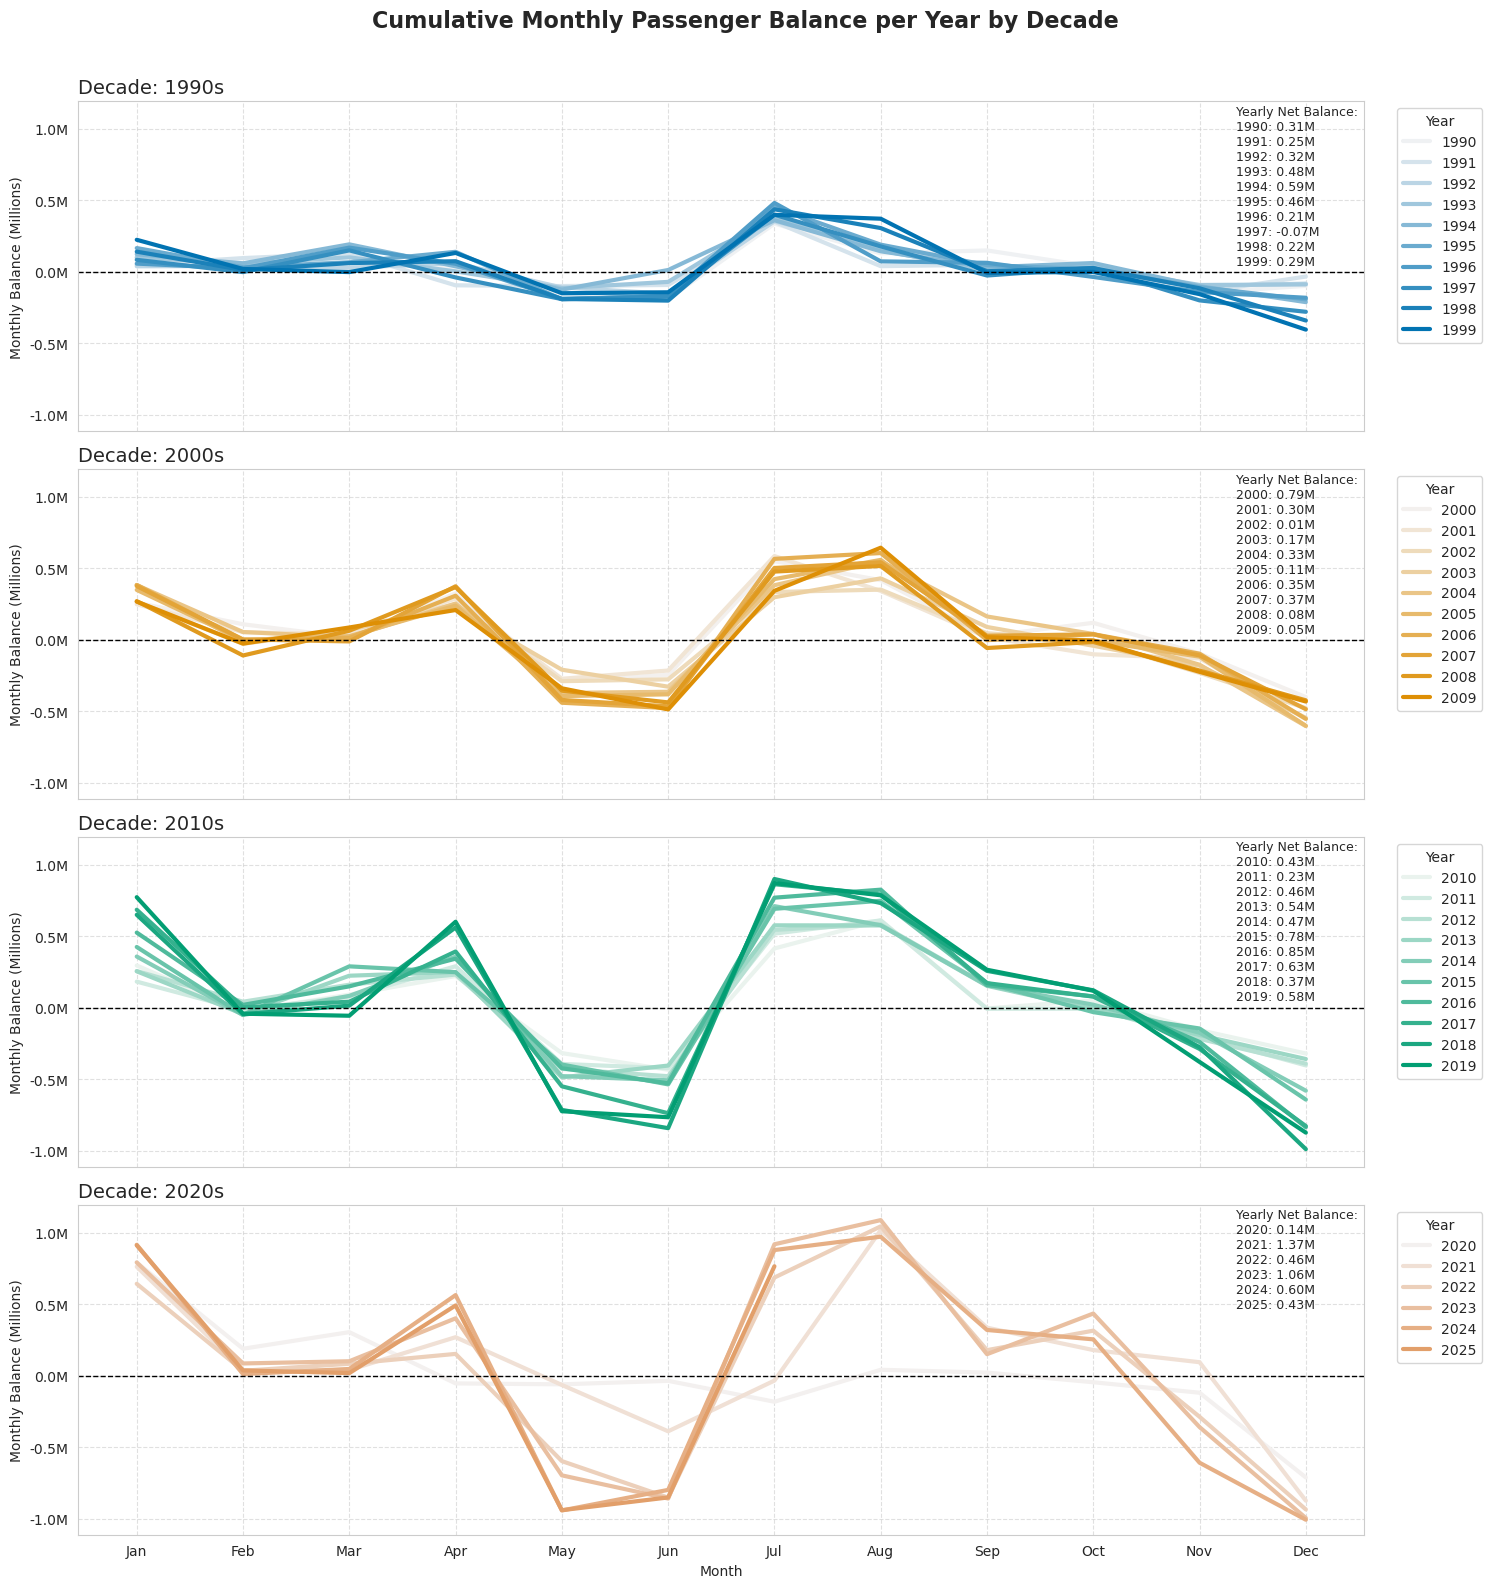

In [5]:
plot_df = df.groupby(['YEAR', 'MONTH', 'Travel_type'], as_index=False)['PASSENGERS'].sum()
data = plot_df.loc[plot_df.Travel_type.isin(['Inbound International', 'Outbound International'])]

balance_df_monthly = data.pivot_table(
    index=['YEAR', 'MONTH'],
    columns='Travel_type',
    values='PASSENGERS'
).fillna(0)
balance_df_monthly['balance'] = balance_df_monthly['Inbound International'] - balance_df_monthly['Outbound International']
plot_data = balance_df_monthly.reset_index()

# --- 3. Create Decade Feature ---
plot_data['decade'] = (plot_data['YEAR'] // 10) * 10
month_labels = [pd.to_datetime(str(m), format='%m').strftime('%b') for m in range(1, 13)]
decades = sorted(plot_data['decade'].unique())
num_decades = len(decades)

yearly_totals = plot_data.groupby('YEAR')['balance'].sum()

# --- 4. Create the Plot ---
sns.set_style("whitegrid")
fig, axes = plt.subplots(
    num_decades, 
    1, 
    figsize=(15, 4 * num_decades), 
    sharex=True, # Share the x-axis
    sharey=True  # <-- ADD THIS LINE to share the y-axis
)
fig.suptitle('Cumulative Monthly Passenger Balance per Year by Decade', fontsize=16, fontweight='bold', y=0.99)

base_colors = sns.color_palette("colorblind", num_decades)

# --- 5. Loop Through Decades and Create Subplots ---
for i, decade in enumerate(decades):
    ax = axes[i]
    decade_data = plot_data[plot_data['decade'] == decade]
    
    years_in_decade = sorted(decade_data['YEAR'].unique())
    n_colors = max(10, len(years_in_decade))
    custom_palette_list = sns.light_palette(base_colors[i], n_colors=n_colors)
    color_map = dict(zip(years_in_decade, custom_palette_list))
    
    sns.lineplot(
        data=decade_data,
        x='MONTH',
        y='balance',
        hue='YEAR',
        palette=color_map,
        ax=ax,
        legend='full',
        linewidth=3
    )
    
    ax.set_title(f"Decade: {decade}s", loc='left', fontsize=14)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    
    formatter = FuncFormatter(lambda y, pos: f'{y / 1_000_000:.1f}M')
    ax.yaxis.set_major_formatter(formatter)
    
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.set_ylabel('Monthly Balance (Millions)')
    ax.set_xlabel('Month')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    ax.legend(title='Year', bbox_to_anchor=(1.02, 1), loc='upper left')

    # --- Add Text Box with Yearly Totals ---
    # Get the totals for the current decade
    decade_totals = yearly_totals[yearly_totals.index.isin(years_in_decade)]
    
    # Format the text
    text_to_display = "Yearly Net Balance:\n" + "\n".join(
        [f"{year}: {total/1_000_000:.2f}M" for year, total in decade_totals.items()]
    )
    
    # Place the text box in the top right corner of the plot
    ax.text(
        0.9, 0.99, # x, y coordinates (as a fraction of the axes)
        text_to_display,
        transform=ax.transAxes, # Use axes-relative coordinates
        fontsize=9,
        verticalalignment='top',
        horizontalalignment='left'
    )

plt.tight_layout(rect=[0, 0, 1, 0.98])
fig = ax.get_figure()
fig.savefig(results_output_path / "figures" / "monthly_balance_international_passengers_by_decade.png", dpi=300)

## Figure Conclusions
- Students leaving the country in May and June to go back home and then coming back into the country in Jul and Aug for the next semester
- Students and Americans leave the country in Nov and Dec to go back home or go on vacation and then come back in Jan
- Every year had a net positive balance, except for 1997
    - Perhaps the 1997 Asian financial crisis contributed to this?
        - People from East and Southeast Asia living in the US were more likely to go home?

In [6]:
intl_df = df.loc[(df.ORIGIN_COUNTRY != 'US') | (df.DEST_COUNTRY != 'US')].copy()
intl_df['foreign_continent'] = intl_df['Travel_type_continent'].str.split(r' from | to ').str[-1]

In [7]:
group1 = intl_df.groupby(['YEAR', 'MONTH', 'date', 'foreign_continent', 'Travel_type'])['PASSENGERS'].sum().unstack().fillna(0).reset_index()

df_grouped = group1.groupby(['YEAR', 'MONTH', 'date', 'foreign_continent']).agg({
    'Inbound International': 'sum',
    'Outbound International': 'sum'
}).reset_index()

df_grouped['net_balance'] = df_grouped['Inbound International'] - df_grouped['Outbound International']


<Figure size 1500x700 with 0 Axes>

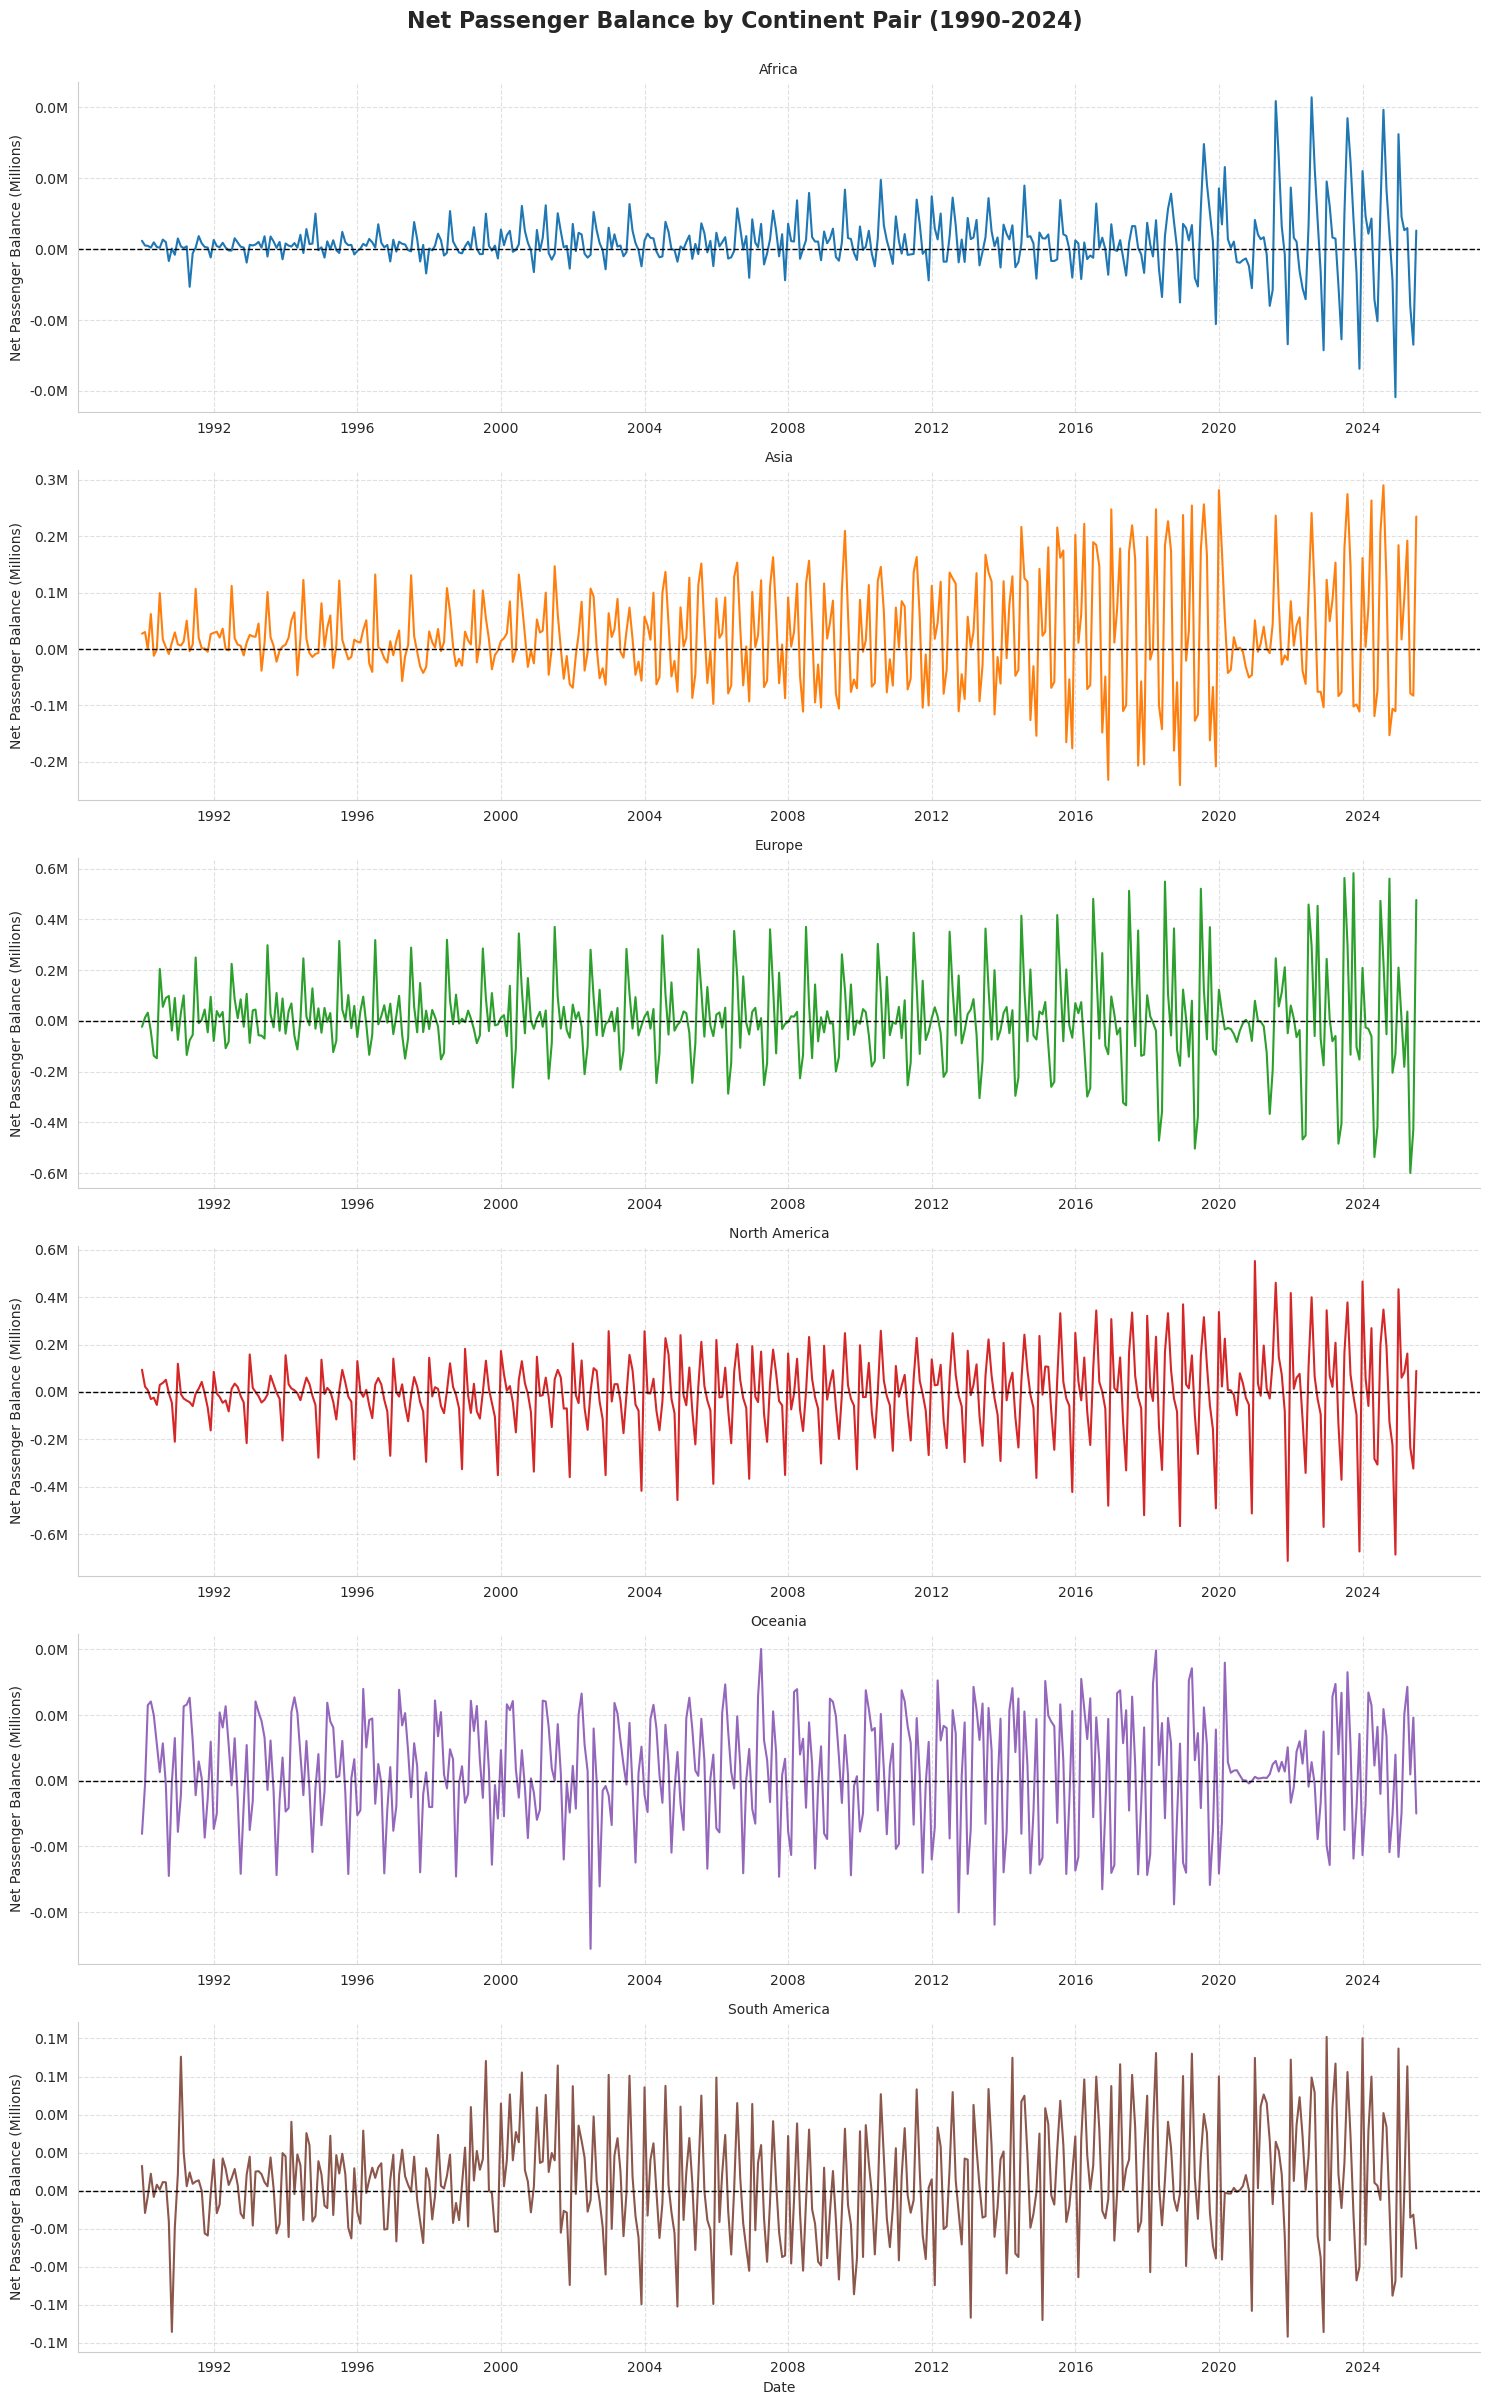

In [8]:
plt.figure(figsize=(15, 7))

g = sns.relplot(
    data=df_grouped,
    x='date',
    y='net_balance',
    row='foreign_continent',  # Create a new column of plots for each pair
    hue='foreign_continent',  # Color each line differently
    kind='line',
    height=4,              # Height of each subplot
    aspect=3.75,
    facet_kws={'sharex': False, 'sharey': False},            # Width-to-height ratio
    legend=False           # We'll use subplot titles instead of a legend
)

# --- 2. Format the Axes ---
# Define the y-axis formatter
formatter = FuncFormatter(lambda y, pos: f'{y / 1_000_000:.1f}M')

# Loop through each subplot (axis) to format it
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(formatter)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.grid(True, linestyle='--', alpha=0.6)

# --- 3. Add Titles and Labels ---
g.set_axis_labels("Date", "Net Passenger Balance (Millions)")
g.set_titles("{row_name}") # Set title for each subplot
g.fig.suptitle('Net Passenger Balance by Continent Pair (1990-2024)', fontsize=16, fontweight='bold', y=1)

plt.tight_layout()
fig = g.fig
fig.savefig(results_output_path / "figures" / "Net_passenger_balance_by_continent.png", dpi=300)

## Figure Conclusions
- Not a very good figure
    - Next figures are better

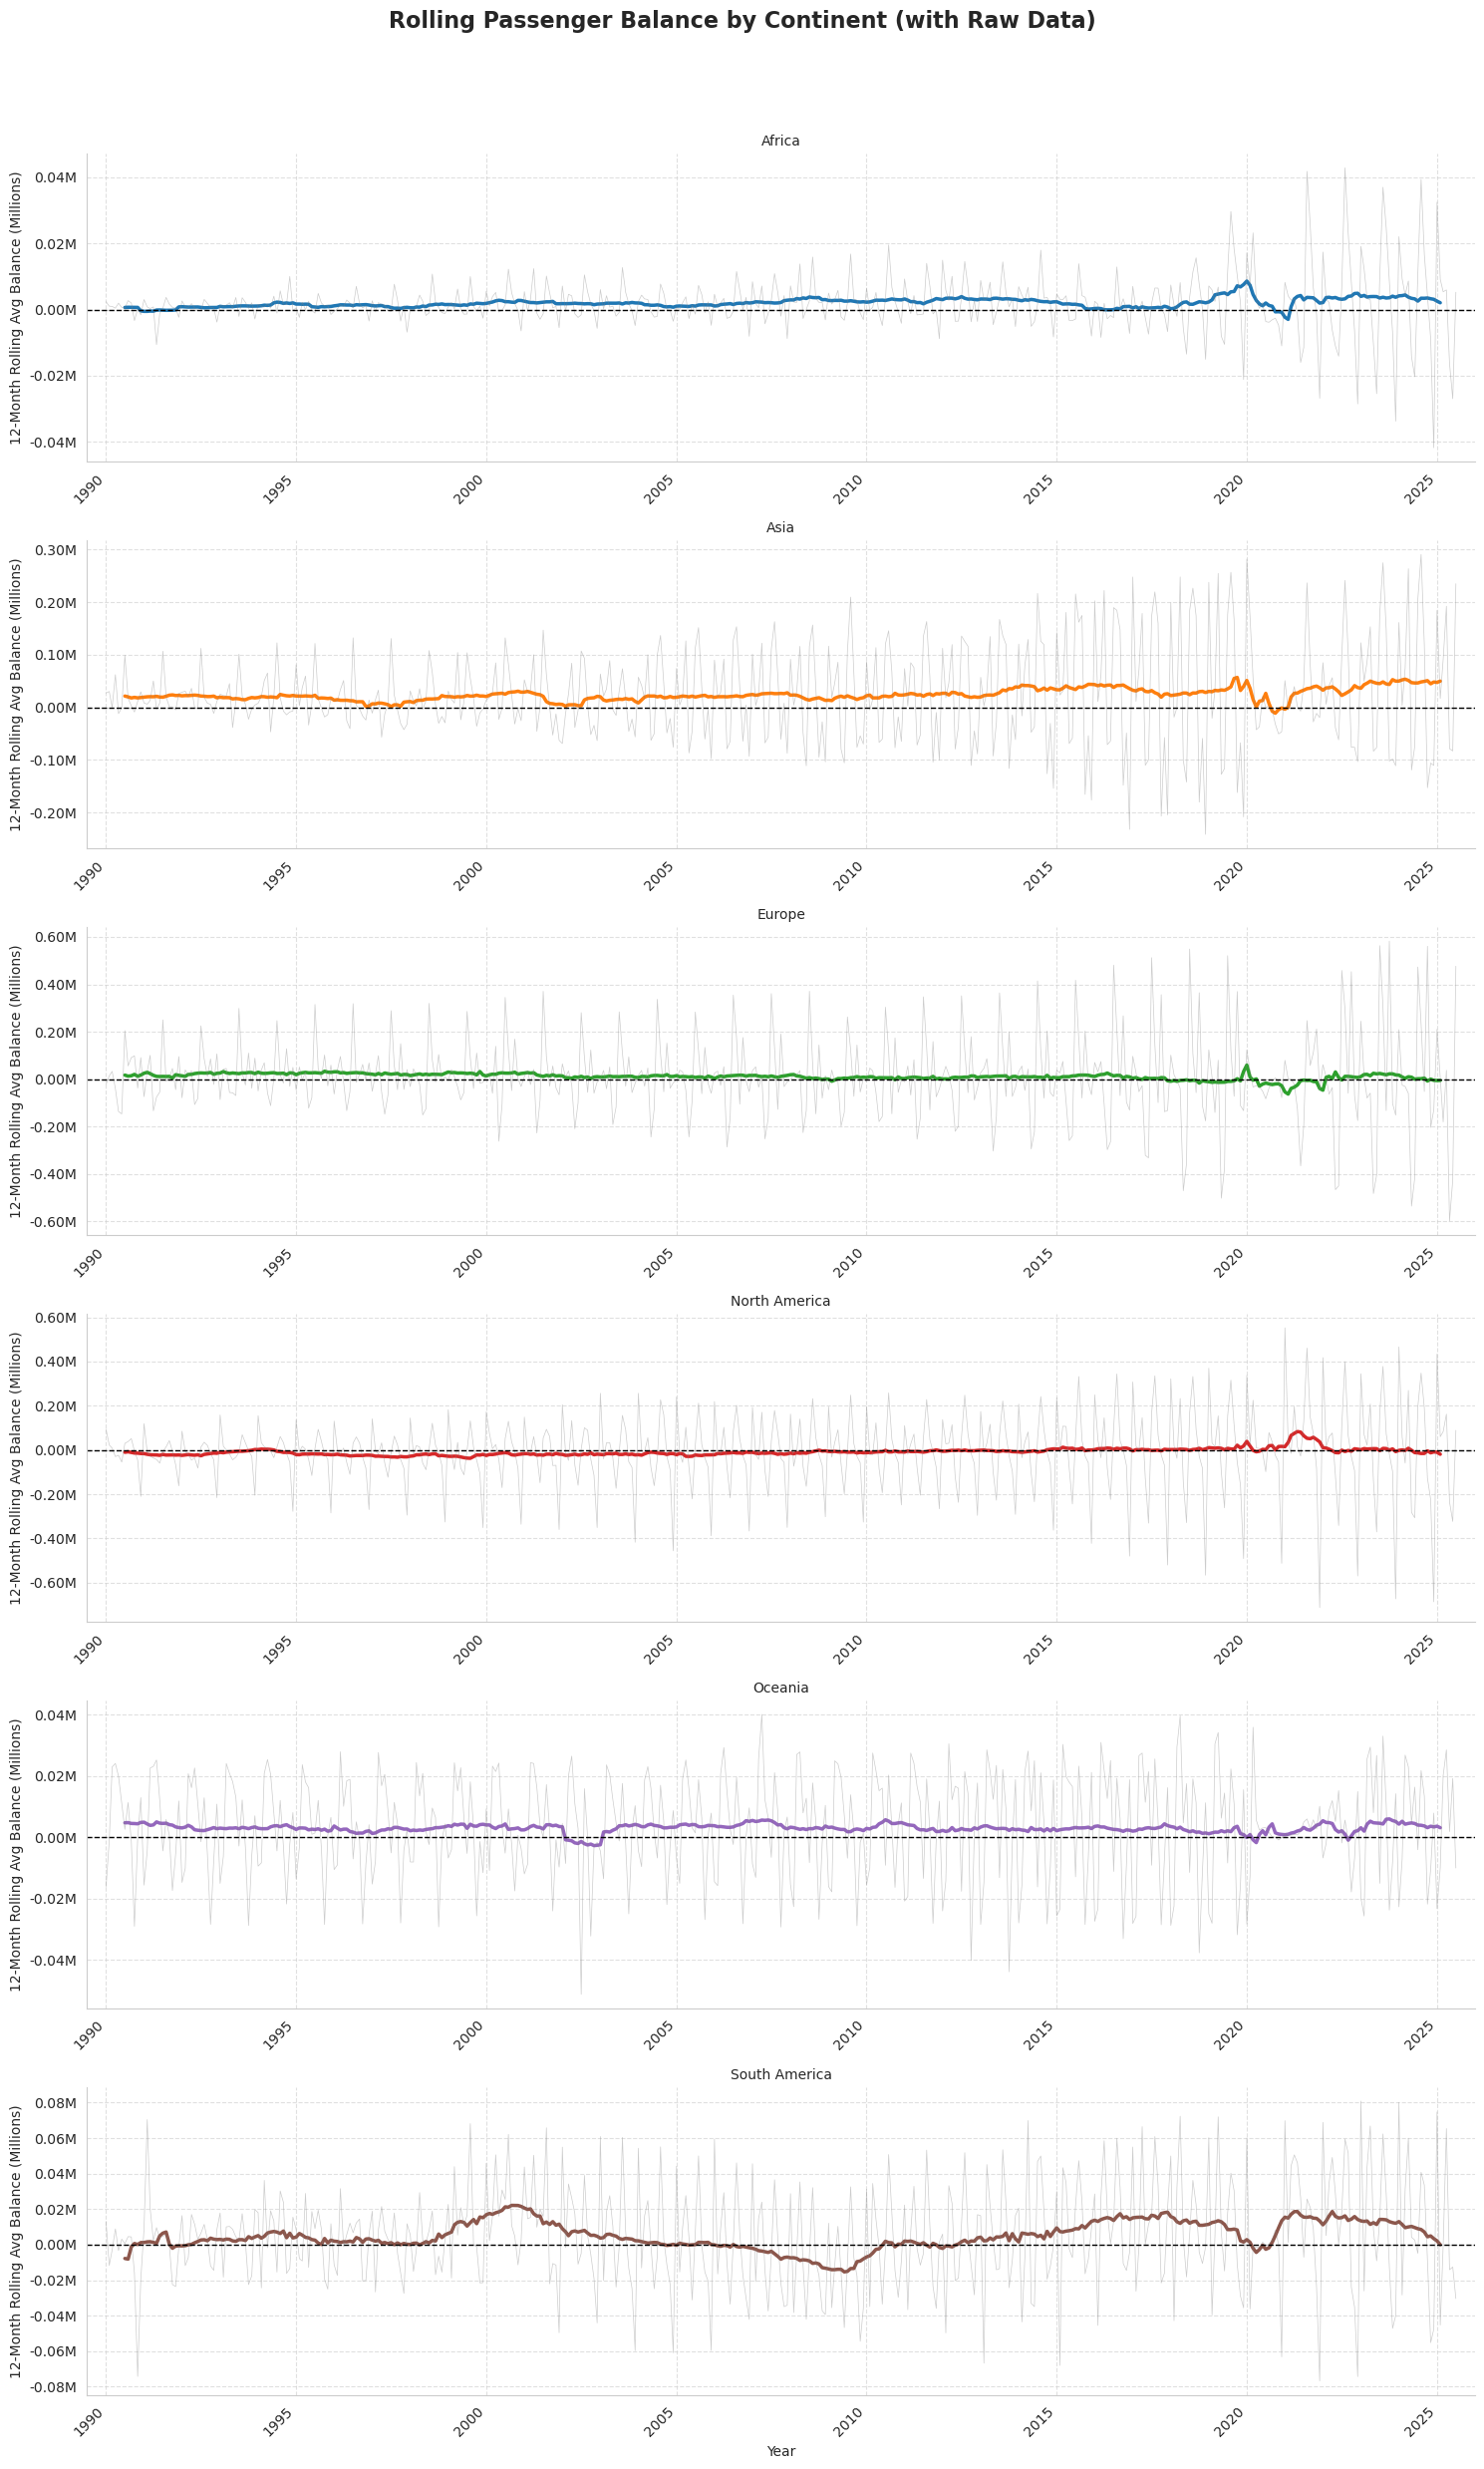

In [9]:
balance_df_monthly = intl_df.pivot_table(
    index=['YEAR', 'MONTH', 'foreign_continent'], 
    columns='Travel_type', 
    values='PASSENGERS',
    aggfunc='sum'
).fillna(0)

balance_df_monthly['balance'] = balance_df_monthly['Inbound International'] - balance_df_monthly['Outbound International']
balance_df_monthly.reset_index(inplace=True)
balance_df_monthly['date'] = pd.to_datetime(balance_df_monthly[['YEAR', 'MONTH']].assign(DAY=1))
balance_df_monthly = balance_df_monthly.sort_values(by=['foreign_continent', 'date'])

# --- 2. Calculate 12-Month Rolling Average ---
balance_df_monthly['rolling_avg_balance'] = balance_df_monthly.groupby('foreign_continent')['balance'] \
                                                              .rolling(window=12, center=True) \
                                                              .mean() \
                                                              .reset_index(level=0, drop=True)

# --- 3. Create the Faceted Plot ---
g = sns.relplot(
    data=balance_df_monthly,
    x='date',
    y='rolling_avg_balance', # This plots the main (rolling) line
    row='foreign_continent',
    hue='foreign_continent', # This colors the main (rolling) line
    kind='line',
    height=4,
    aspect=3.75,
    legend=False,
    facet_kws={'sharex': False, 'sharey': False},
    linewidth=2.5 # Make the rolling line thicker
)

# --- 4. Format the Axes (and add the raw data plot) ---
formatter = FuncFormatter(lambda y, pos: f'{y / 1_000_000:.2f}M')
min_date = balance_df_monthly['date'].min() - pd.DateOffset(months=6)
max_date = balance_df_monthly['date'].max() + pd.DateOffset(months=6)

# Loop through each subplot (axis) to format it
for continent, ax in g.axes_dict.items():
    
    # --- Add the raw 'balance' data as a faint line ---
    # Filter the full dataframe for this continent's raw data
    continent_data = balance_df_monthly[balance_df_monthly['foreign_continent'] == continent]
    sns.lineplot(
        data=continent_data,
        x='date',
        y='balance', # Plot the raw 'balance'
        ax=ax,
        color='grey', # Use a neutral color
        alpha=0.4,
        linewidth=0.5,
        legend=False
    )
    
    # --- Apply your existing formatting ---
    ax.yaxis.set_major_formatter(formatter)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    ax.xaxis.set_major_locator(YearLocator(5))
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))

    ax.set_xlim(min_date, max_date)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# --- 5. Add Titles and Labels ---
g.set_axis_labels("Year", "12-Month Rolling Avg Balance (Millions)")
g.set_titles("{row_name}")
g.fig.suptitle('Rolling Passenger Balance by Continent (with Raw Data)', fontsize=16, fontweight='bold', y=1.03)

plt.tight_layout()
fig = g.fig
fig.savefig(results_output_path / "figures" / "Rolling_passenger_balance_by_continent_with_raw_data.png", dpi=300)

# Figure Conclusions
- Better but still not great

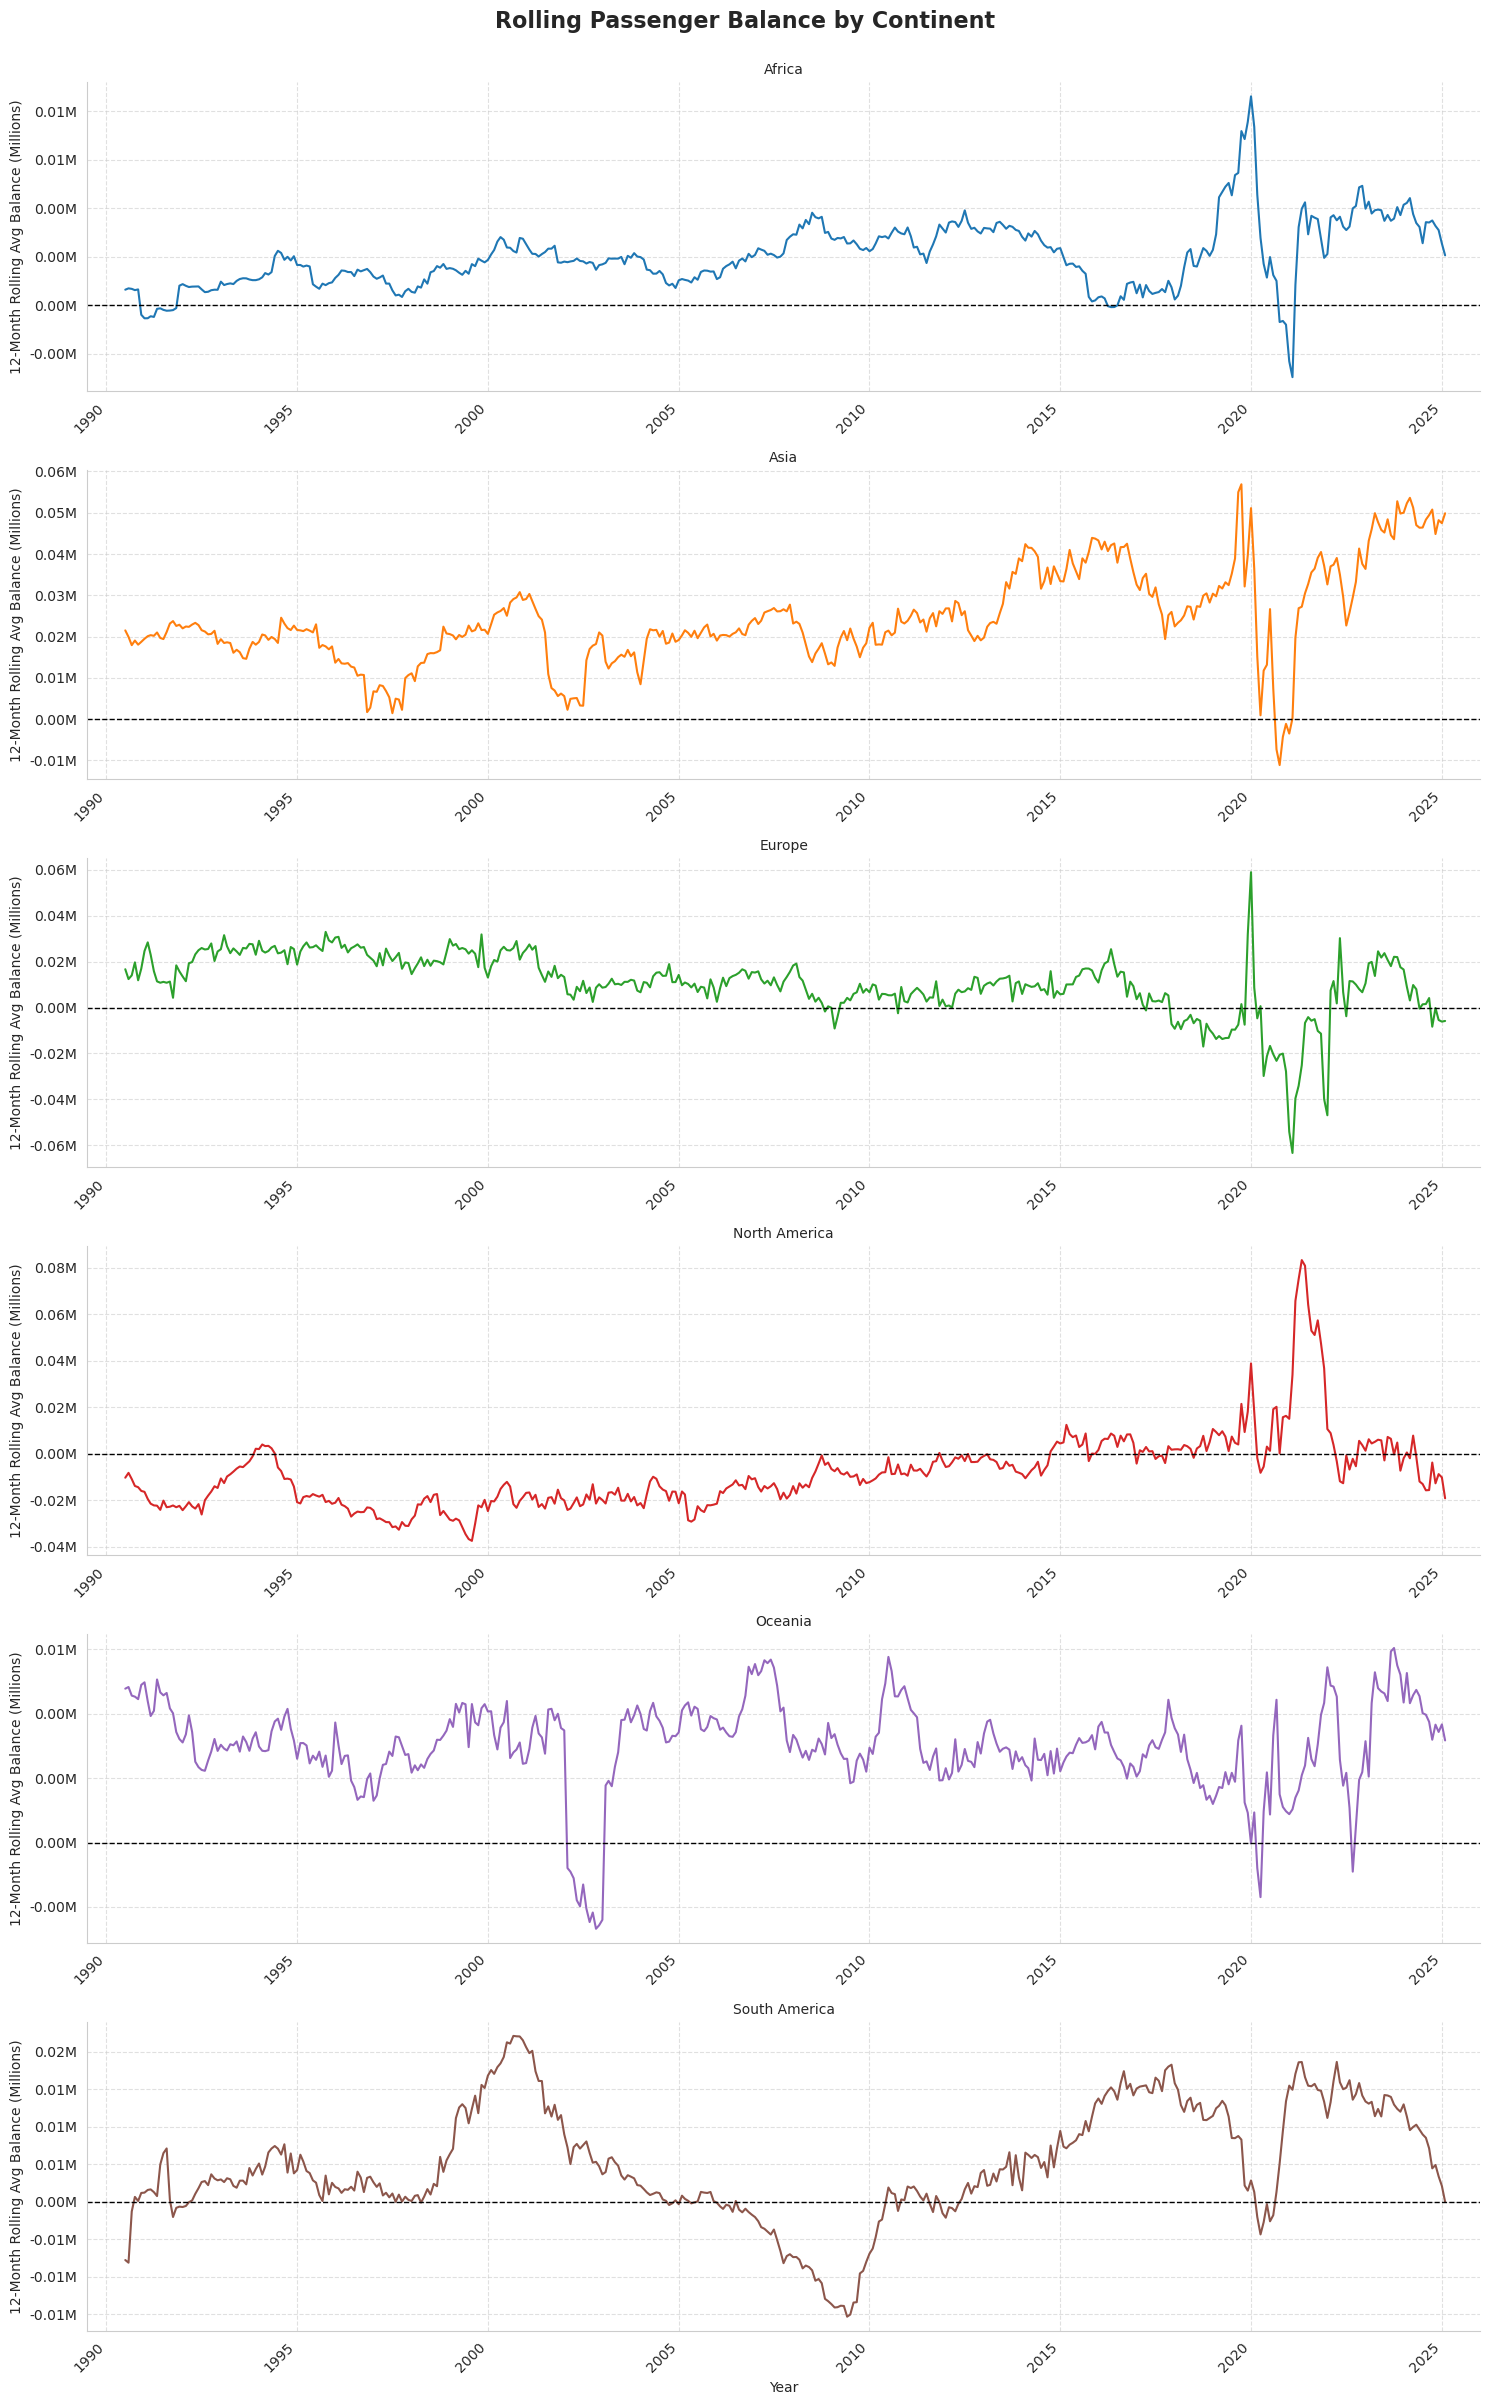

In [10]:
balance_df_monthly = intl_df.pivot_table(
    index=['YEAR', 'MONTH', 'foreign_continent'], 
    columns='Travel_type', 
    values='PASSENGERS',
    aggfunc='sum'
).fillna(0)


balance_df_monthly['balance'] = balance_df_monthly['Inbound International'] - balance_df_monthly['Outbound International']
balance_df_monthly.reset_index(inplace=True)
balance_df_monthly['date'] = pd.to_datetime(balance_df_monthly[['YEAR', 'MONTH']].assign(DAY=1))
balance_df_monthly = balance_df_monthly.sort_values(by=['foreign_continent', 'date'])

# --- 2. Calculate 12-Month Rolling Average ---
balance_df_monthly['rolling_avg_balance'] = balance_df_monthly.groupby('foreign_continent')['balance'] \
                                                              .rolling(window=12, center=True) \
                                                              .mean() \
                                                              .reset_index(level=0, drop=True)

# --- 3. Create the Faceted Plot ---
g = sns.relplot(
    data=balance_df_monthly,
    x='date',
    y='rolling_avg_balance',
    row='foreign_continent',
    hue='foreign_continent',
    kind='line',
    height=4,
    aspect=3.75,
    legend=False,
    facet_kws={'sharex': False, 'sharey': False}
)

# --- 4. Format the Axes ---
formatter = FuncFormatter(lambda y, pos: f'{y / 1_000_000:.2f}M')

min_date = balance_df_monthly['date'].min() - pd.DateOffset(months=6)
max_date = balance_df_monthly['date'].max() + pd.DateOffset(months=6)

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(formatter)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    ax.xaxis.set_major_locator(YearLocator(5))
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))

    ax.set_xlim(min_date, max_date)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# --- 5. Add Titles and Labels ---
g.set_axis_labels("Year", "12-Month Rolling Avg Balance (Millions)")
g.set_titles("{row_name}")
g.fig.suptitle('Rolling Passenger Balance by Continent', fontsize=16, fontweight='bold', y=1)

plt.tight_layout()
fig = g.fig
fig.savefig(results_output_path / "figures" / "Rolling_passenger_balance_by_continent.png", dpi=300)

## Figure Conclusions
- First off, I think the peak/dip differences around 2019/2020 could be due to whether travel shutdown during/right after the seasonal peak or dip
    - Not that some continenets experienced a large surplus/deficit to the US right before the pandemic
- Interesting trends and some outliers like Oceania in 2002-2003
- The data anomolies suggest that maybe there are underlying causes for this shift in the data
    - Perhaps changes in the way data is counted

In [11]:
country_df = df.copy()

conditions = [
    (df['ORIGIN_COUNTRY'] == 'US') & (df['DEST_COUNTRY'] == 'US'),
    (df['ORIGIN_COUNTRY'] != 'US') & (df['DEST_COUNTRY'] == 'US'),
    (df['ORIGIN_COUNTRY'] == 'US') & (df['DEST_COUNTRY'] != 'US')
]

choices_country = [
    'Domestic',
    'Inbound from ' + df['origin_country_name'],
    'Outbound to ' + df['dest_country_name']
]

country_df['Travel_type_country'] = np.select(conditions, choices_country, default='Other')
country_df = country_df[(country_df.ORIGIN_COUNTRY != 'US') | (country_df.DEST_COUNTRY != 'US')].copy()
country_df['foreign_country'] = country_df['Travel_type_country'].str.split(r' from | to ').str[-1]

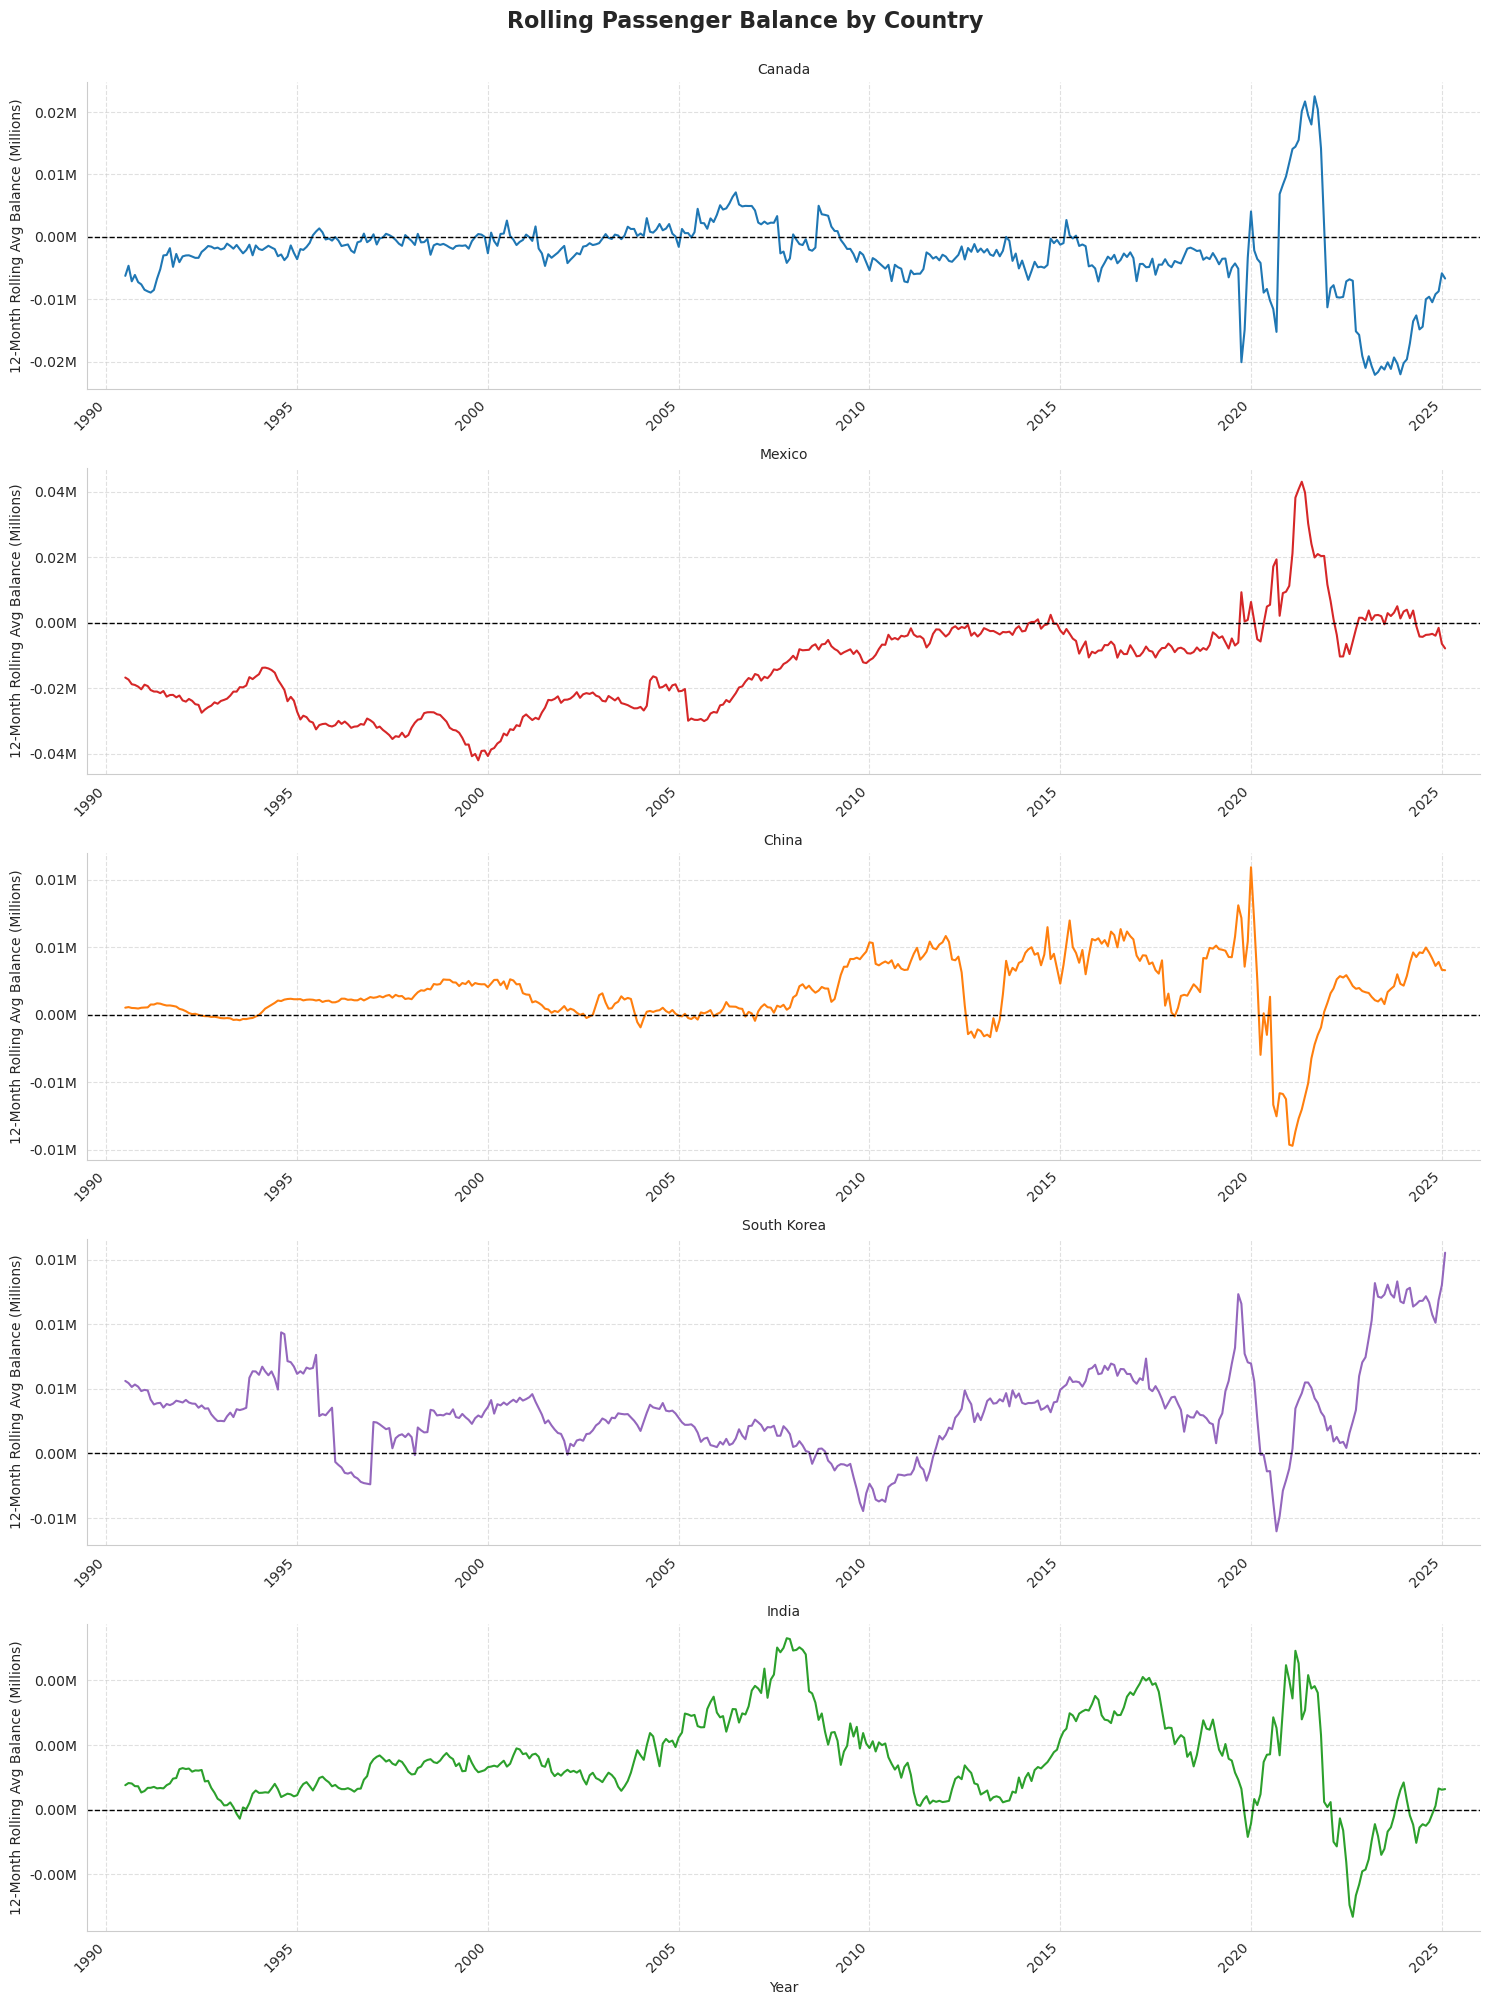

In [12]:
country_df.reset_index()['foreign_country'] = np.where(
    country_df.reset_index()['Travel_type'] == 'Outbound International', 
    country_df.reset_index()['dest_country_name'],
    country_df.reset_index()['origin_country_name']
)

# --- 2. Filter for Your Target Countries ---
target_countries = ['Canada', 'Mexico', 'China', 'South Korea', 'India']
df_filtered = country_df[country_df['foreign_country'].isin(target_countries)]

# --- 3. Calculate Rolling Balance ---
balance_df_monthly = df_filtered.pivot_table(
    index=['YEAR', 'MONTH', 'foreign_country'], 
    columns='Travel_type', 
    values='PASSENGERS',
    aggfunc='sum'
).fillna(0)


balance_df_monthly['balance'] = balance_df_monthly['Inbound International'] - balance_df_monthly['Outbound International']
balance_df_monthly.reset_index(inplace=True)
balance_df_monthly['date'] = pd.to_datetime(balance_df_monthly[['YEAR', 'MONTH']].assign(DAY=1))
balance_df_monthly = balance_df_monthly.sort_values(by=['foreign_country', 'date'])

balance_df_monthly['rolling_avg_balance'] = balance_df_monthly.groupby('foreign_country')['balance'] \
                                                              .rolling(window=12, center=True) \
                                                              .mean() \
                                                              .reset_index(level=0, drop=True)

# --- 4. Create the Faceted Plot ---
g = sns.relplot(
    data=balance_df_monthly,
    x='date',
    y='rolling_avg_balance',
    row='foreign_country', # Use country name for the rows
    hue='foreign_country', # Use country name for the color
    row_order=target_countries, # Ensure the order is correct
    kind='line',
    height=4,
    aspect=3.75,
    legend=False,
    facet_kws={'sharex': False, 'sharey': False}
)

# --- 4. Format the Axes ---
formatter = FuncFormatter(lambda y, pos: f'{y / 1_000_000:.2f}M')
min_date = balance_df_monthly['date'].min() - pd.DateOffset(months=6)
max_date = balance_df_monthly['date'].max() + pd.DateOffset(months=6)

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(formatter)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    ax.xaxis.set_major_locator(YearLocator(5))
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))
    ax.set_xlim(min_date, max_date)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# --- 5. Add Titles and Labels ---
g.set_axis_labels("Year", "12-Month Rolling Avg Balance (Millions)")
g.set_titles("{row_name}")
g.fig.suptitle('Rolling Passenger Balance by Country', fontsize=16, fontweight='bold', y=1)

plt.tight_layout()
fig = g.fig
fig.savefig(results_output_path / "figures" / "Rolling_passenger_balance_by_country.png", dpi=300)

## Figure Conclusions
- Looking at 5 countires of interest, there appears to be large fluctuations thoughout the years
    - Are these fluctuations real, or are they due to changed in data collections?

In [13]:
parquet_path = "../data/T100_International/final_enriched_data.parquet"
t100_intl_df = pd.read_parquet(parquet_path)

In [14]:
t100_intl_df.usg_country_name.value_counts()

usg_country_name
United States                           772305
Puerto Rico                              17019
Guam                                     11200
Northern Mariana Islands                  3903
U.S. Virgin Islands                       1479
American Samoa                             766
Palau                                      143
Turkey                                     103
United States Minor Outlying Islands        25
Peru                                        11
Brazil                                       7
Indonesia                                    5
Iran                                         3
Pakistan                                     2
Colombia                                     2
Russia                                       2
Papua New Guinea                             1
Name: count, dtype: int64

In [31]:
pd.DataFrame({'Count of Nulls': t100_intl_df.isna().sum(),'Dtype': t100_intl_df.dtypes})

,Count of Nulls,Dtype
data_dte,0,datetime64[ns]
year,0,int64
month,0,int64
usg_apt_id,0,int64
usg_apt,0,object
usg_wac,0,int64
fg_apt_id,0,int64
fg_apt,0,object
fg_wac,0,int64
airlineid,0,int64


In [33]:
target_countries = ['Canada', 'Mexico', 'China', 'South Korea', 'India']

domestic_t100_df = df.loc[((df['DEST_COUNTRY_NAME'].isin(target_countries)) & (df['ORIGIN_COUNTRY_NAME'] == 'United States')) | ((df['DEST_COUNTRY_NAME'] == 'United States') & (df['ORIGIN_COUNTRY_NAME'].isin(target_countries)))][['ORIGIN_COUNTRY_NAME', 'ORIGIN', 'DEST_COUNTRY_NAME', 'DEST', 'date', 'PASSENGERS', 'Travel_type']].rename(columns={'date': 'DATE'})
domestic_t100_df = domestic_t100_df.assign(source='T100_Domestic')
domestic_t100_df['foreign_country'] = np.where(
    domestic_t100_df['ORIGIN_COUNTRY_NAME'] == 'United States',
    domestic_t100_df['DEST_COUNTRY_NAME'],
    domestic_t100_df['ORIGIN_COUNTRY_NAME']
)

international_t100_df = t100_intl_df.loc[(t100_intl_df['fg_country_name'].isin(target_countries)) & (t100_intl_df['usg_country_name'] == 'United States')][['usg_country_name', 'usg_apt_id', 'fg_country_name', 'fg_apt_id', 'data_dte', 'total']].rename(columns={'usg_country_name': 'ORIGIN_COUNTRY_NAME', 'usg_apt_id': 'ORIGIN', 'fg_country_name': 'DEST_COUNTRY_NAME', 'fg_apt_id': 'DEST', 'data_dte': 'DATE', 'total': 'PASSENGERS'})
international_t100_df = international_t100_df.assign(source='T100_International')
international_t100_df = international_t100_df.assign(Travel_type='Outbound International')
international_t100_df['foreign_country'] = np.where(
    international_t100_df['ORIGIN_COUNTRY_NAME'] == 'United States',
    international_t100_df['DEST_COUNTRY_NAME'],
    international_t100_df['ORIGIN_COUNTRY_NAME']
)

domestic_and_international_t100_df = pd.concat([international_t100_df, domestic_t100_df], ignore_index=True)
domestic_and_international_t100_df.groupby(['ORIGIN_COUNTRY_NAME', 'DEST_COUNTRY_NAME', 'foreign_country', 'DATE', 'source'])['PASSENGERS'].sum().reset_index()

plot_df = domestic_and_international_t100_df.groupby(['ORIGIN_COUNTRY_NAME', 'DEST_COUNTRY_NAME', 'foreign_country', 'DATE', 'source', 'Travel_type'])['PASSENGERS'].sum().reset_index()

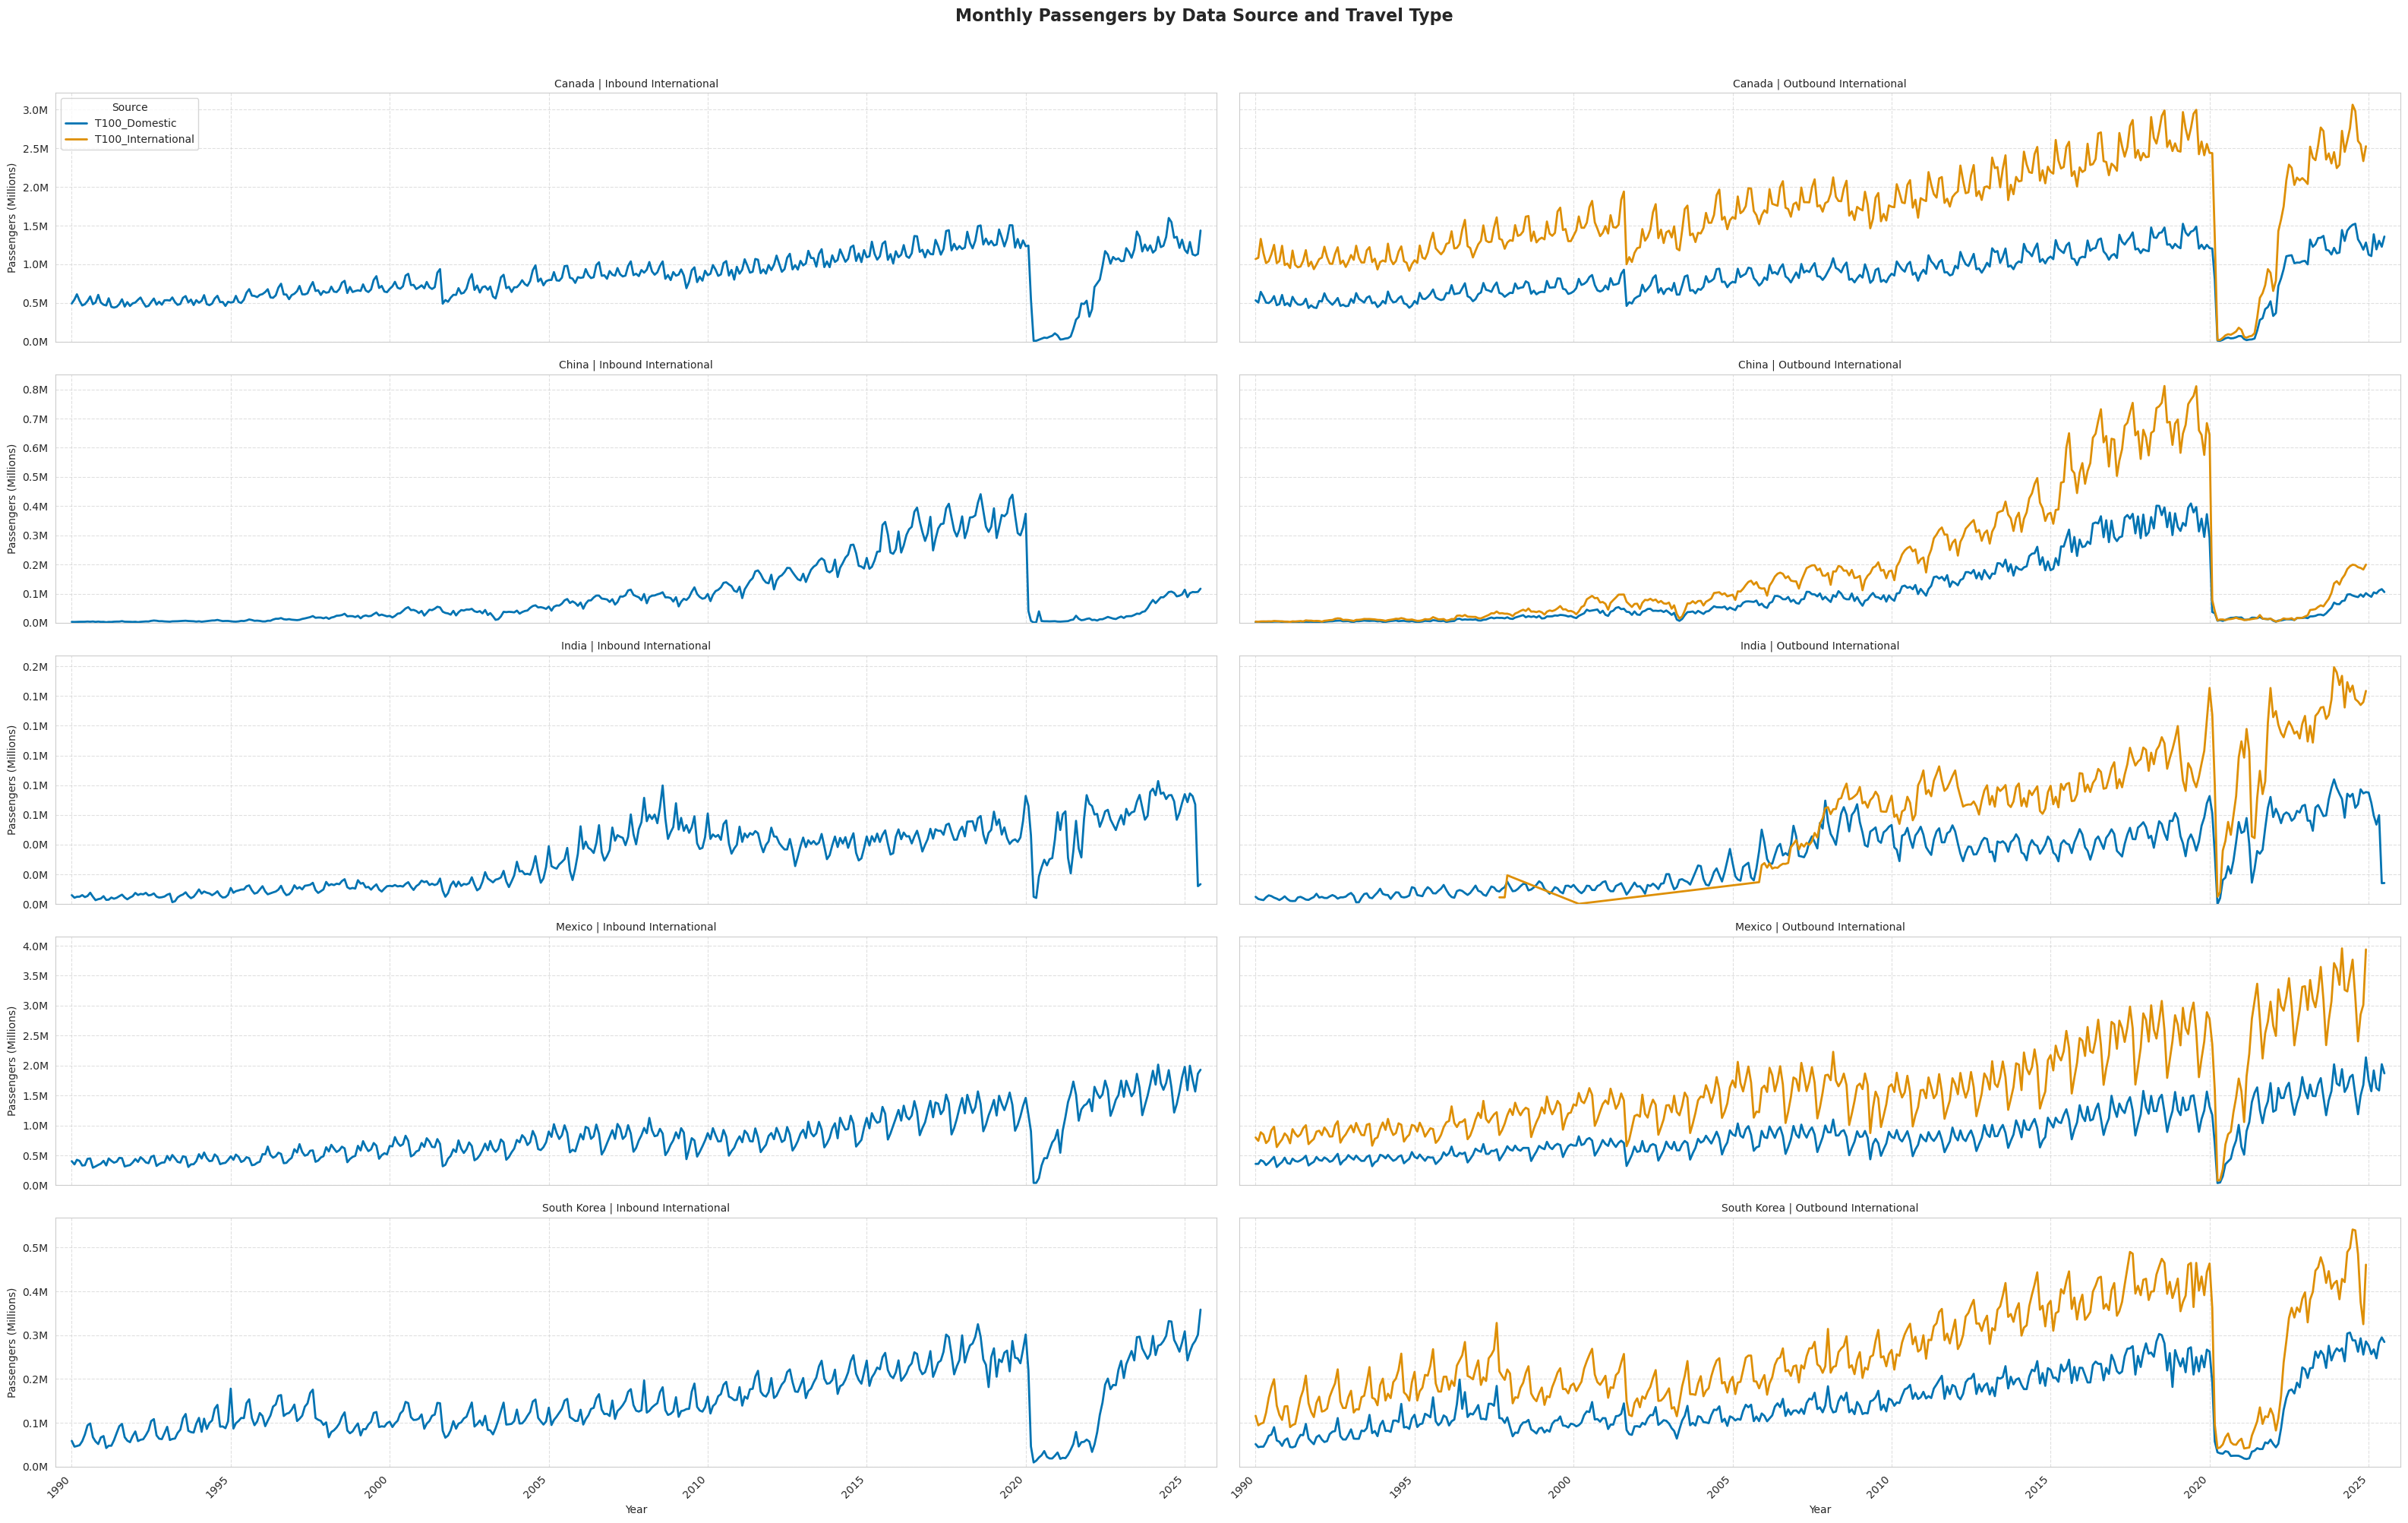

<Figure size 640x480 with 0 Axes>

In [ ]:
sns.set_style("whitegrid")

# --- 2. Create the Faceted Plot ---
g = sns.relplot(
    data=plot_df,
    x='DATE',
    y='PASSENGERS',
    hue='source',
    col='Travel_type',
    row='foreign_country',
    kind='line',
    palette='colorblind',
    linewidth=2,
    height=4,
    aspect=3.75,
    facet_kws={'sharey': 'row'},
    legend=True  # <-- Let seaborn create the legend (we'll move it)
)

# --- 3. Format the Axes ---
formatter = FuncFormatter(lambda y, pos: f'{y / 1_000_000:.1f}M')
min_date = plot_df['DATE'].min() - pd.DateOffset(months=6)
max_date = plot_df['DATE'].max() + pd.DateOffset(months=6)

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(formatter)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.xaxis.set_major_locator(YearLocator(5))
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))
    ax.set_xlim(min_date, max_date)
    ax.set_ylim(0, ax.get_ylim()[1])
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# --- 4. Move the Legend ---
# Get the handles and labels from the figure-level legend
handles = g._legend_data.values()
labels = g._legend_data.keys()

# Turn off the original, misplaced legend
g.legend.remove()

# Add the legend to the first subplot (axes[0, 0])
g.axes[0, 0].legend(handles=handles, labels=labels, loc='upper left', title='Source')

# --- 5. Add Titles and Labels ---
g.set_axis_labels("Year", "Passengers (Millions)")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.fig.suptitle('Monthly Passengers by Data Source and Travel Type', fontsize=16, fontweight='bold', y=1)

# --- 6. Despine and Save ---
g.despine(top=False, right=False)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

plt.savefig(results_output_path / 't100_domestic_vs_international_country_comparison.png', dpi=300)

## Figure Conclusions
- It appears the T100 international dataset my be the international segments of the T100 domestic dataset, but merged
    - The domestic T100 dataset specifies origin and destination, whereas the international T100 dataset only specifies USG and FG airport

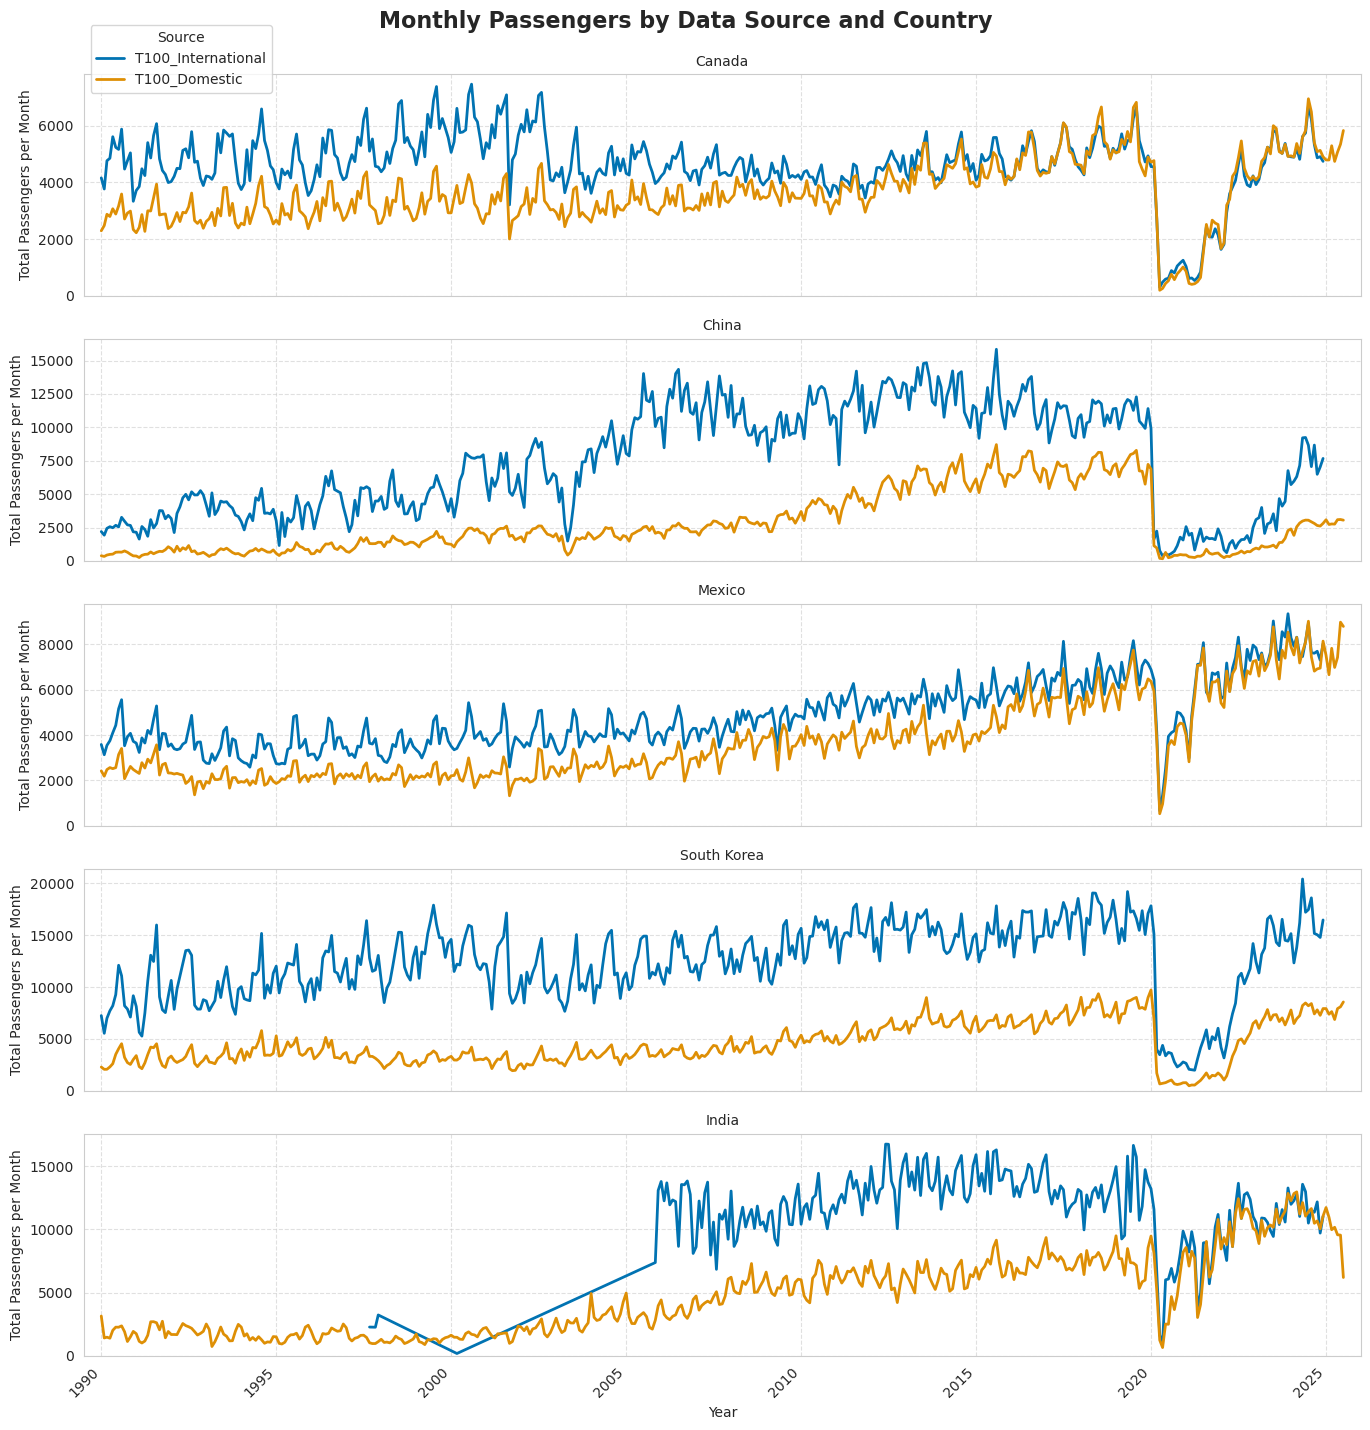

In [25]:
sns.set_style("whitegrid")

# --- 2. Create the Faceted Plot ---
g = sns.relplot(
    data=plot_df,
    x='DATE',
    y='total',
    hue='source',
    row='foreign_country', # Create a row for each country
    kind='line',
    palette='colorblind',  # Use a colorblind-friendly palette
    linewidth=2,
    height=3,               # Height of each subplot
    aspect=4,               # Width-to-height ratio (makes it 12 inches wide)
    facet_kws={'sharey': False} # Keep y-axes independent
)

# --- 3. Format the Axes ---
min_date = plot_df['DATE'].min() - pd.DateOffset(months=6)
max_date = plot_df['DATE'].max() + pd.DateOffset(months=6)

for ax in g.axes.flat:
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.xaxis.set_major_locator(YearLocator(5))
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))
    ax.set_xlim(min_date, max_date)
    ax.set_ylim(0, ax.get_ylim()[1])
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# --- 4. Move the Legend ---
# Get the handles and labels from the figure-level legend
handles = g._legend_data.values()
labels = g._legend_data.keys()

# Turn off the original, misplaced legend
g.legend.remove()

# Add the legend to the first subplot (axes[0, 0])
g.axes[0, 0].legend(handles=handles, labels=labels, loc='upper left', bbox_to_anchor=(0, 1.25), title='Source')

# --- 4. Add Titles and Labels ---
g.set_axis_labels("Year", "Total Passengers per Month")
g.set_titles("{row_name}")
g.fig.suptitle('Monthly Passengers by Data Source and Country', fontsize=16, fontweight='bold', y=0.95)

# --- 5. Despine and Save ---
g.despine(top=False, right=False) # Keep the full box
plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.savefig(results_output_path / 't100_domestic_vs_international_country_comparison_added.png', dpi=300)

## Figure Conslusions
- When grouping domestic T100 international inbound/outbound segments into 1 number, the data only approximately matches the T100 international dataset for some years and for some countries

# Notebook Notes
- The T100 domestic dataset includes international segments in addition to domestic flights
- The T100 domestic dataset specifies origin and destination

## T100 Domestic Dataset Conclusions
- This table combines domestic and international market data reported by U.S. and foreign air carriers, and contains market data by carrier, origin and destination, and service class for enplaned passengers, freight, and mail. For a uniform end date for the combined databases, the last 3 months U.S. carrier domestic data released in T-100 Domestic Market (U.S. Carriers Only) are not included. Flights with both origin and destination in a foreign country are not included.
- https://www.transtats.bts.gov/Tables.asp?QO_VQ=EEE

## T100 International Dataset Conclusions
- The T100 international dataset does NOT specify origin and destination, it just list USG and FG airport/country
    - The T100 international dataset does include examples of flights between foreign airports (USG is not US or US territories), but this number is very small
- The T-100 segment data includes all (US carrier operated and co-listed?) traffic arriving at U.S. airports and departing from U.S. airports on **nonstop** commercial international flights.
    - Absence or low-numbers does not necessarily correlate to the total service provided by U.S. carriers, as many destinationa are served via connecting airports
    - Conversely, traffic on routes that serve as **connecting gateways** will exceed the number of true Origin & Destination (O&D) passengers due to the high percentage of connecting traffic.
- Prior to **October 1st, 2002**, air carriers that operated aircraft with 60 seats or less were not required to file T-100 data. Therefore, passenger volume in markets like the **Caribbean and Canada** was likely understated before this date.
- **Code-share relationships** may cause U.S. carriers to seem under-represented. This data is reported according to the **operating carrier**. In many cases (particularly to Asia), U.S. airlines sell tickets but transport passengers via a foreign code-share partner.
- https://www.transportation.gov/policy/aviation-policy/us-international-air-passenger-and-freight-statistics-report


# Notebook Conclusions
- Use the T100 domestic dataset
    - Has better grainularity due to specifying the origin and destination of the flights
    - Methods used to report data do not seem to have undergone substaintial modifications throughout the dataseta
- The T100 domestic dataset is missing data, I think? 
    - Not explicitly stated anywhere I read, but its not going to properly account for foreign carreirs
- The T100 International dataset is still useful to use
     - Why does it show idenical recovery from covid pandemic for Canada as does the T100 domestic
        - By then why does it show a very different recovery for China?